## Project Overview

You work for a staffing agency that specializes in finding qualified candidates for development roles. One of your latest clients is growing rapidly and wants to understand what kinds of developers they can hire, and to understand general trends of the technology market.

### Exploratory Data Analysis

#### Studying the dataset

In [1]:
import pandas as pd

df = pd.read_csv('developer_dataset.csv')

print(df.columns)


Index(['RespondentID', 'Year', 'Country', 'Employment', 'UndergradMajor',
       'DevType', 'LanguageWorkedWith', 'LanguageDesireNextYear',
       'DatabaseWorkedWith', 'DatabaseDesireNextYear', 'PlatformWorkedWith',
       'PlatformDesireNextYear', 'Hobbyist', 'OrgSize', 'YearsCodePro',
       'JobSeek', 'ConvertedComp', 'WorkWeekHrs', 'NEWJobHunt',
       'NEWJobHuntResearch', 'NEWLearn'],
      dtype='object')


C:\Users\lenovo\AppData\Local\Temp\ipykernel_27756\2946174649.py:3: DtypeWarning: Columns (18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('developer_dataset.csv')


In [2]:
df.count()

RespondentID              111209
Year                      111209
Country                   111209
Employment                109425
UndergradMajor             98453
DevType                   100433
LanguageWorkedWith        102018
LanguageDesireNextYear     96044
DatabaseWorkedWith         85859
DatabaseDesireNextYear     74234
PlatformWorkedWith         91609
PlatformDesireNextYear     85376
Hobbyist                   68352
OrgSize                    54804
YearsCodePro               94793
JobSeek                    60556
ConvertedComp              91333
WorkWeekHrs                51089
NEWJobHunt                 19127
NEWJobHuntResearch         18683
NEWLearn                   24226
dtype: int64

In [3]:
df.describe()

,RespondentID,Year,YearsCodePro,ConvertedComp,WorkWeekHrs
count,111209.000000,111209.000000,94793.000000,9.133300e+04,51089.000000
mean,19262.039709,2018.854832,9.547045,1.251777e+05,41.051670
std,11767.011322,0.777503,7.548931,2.461218e+05,13.833929
min,1.000000,2018.000000,0.000000,0.000000e+00,1.000000
25%,9268.000000,2018.000000,4.000000,4.600000e+04,40.000000
50%,18535.000000,2019.000000,8.000000,7.900000e+04,40.000000
75%,28347.000000,2019.000000,14.000000,1.200000e+05,42.000000
max,42857.000000,2020.000000,50.000000,2.000000e+06,475.000000


#### Delete highly missing data

In [4]:
maxRows = df['RespondentID'].count()

print('% Missing Data:')
print((1 - df.count() / maxRows) * 100)

% Missing Data:
RespondentID               0.000000
Year                       0.000000
Country                    0.000000
Employment                 1.604187
UndergradMajor            11.470295
DevType                    9.689863
LanguageWorkedWith         8.264619
LanguageDesireNextYear    13.636486
DatabaseWorkedWith        22.794918
DatabaseDesireNextYear    33.248208
PlatformWorkedWith        17.624473
PlatformDesireNextYear    23.229235
Hobbyist                  38.537349
OrgSize                   50.719816
YearsCodePro              14.761395
JobSeek                   45.547573
ConvertedComp             17.872654
WorkWeekHrs               54.060373
NEWJobHunt                82.800852
NEWJobHuntResearch        83.200101
NEWLearn                  78.215792
dtype: float64


In [5]:
df.drop(['NEWJobHunt','NEWJobHuntResearch','NEWLearn'],
    axis=1,
    inplace=True)

#### Analyze developers by country

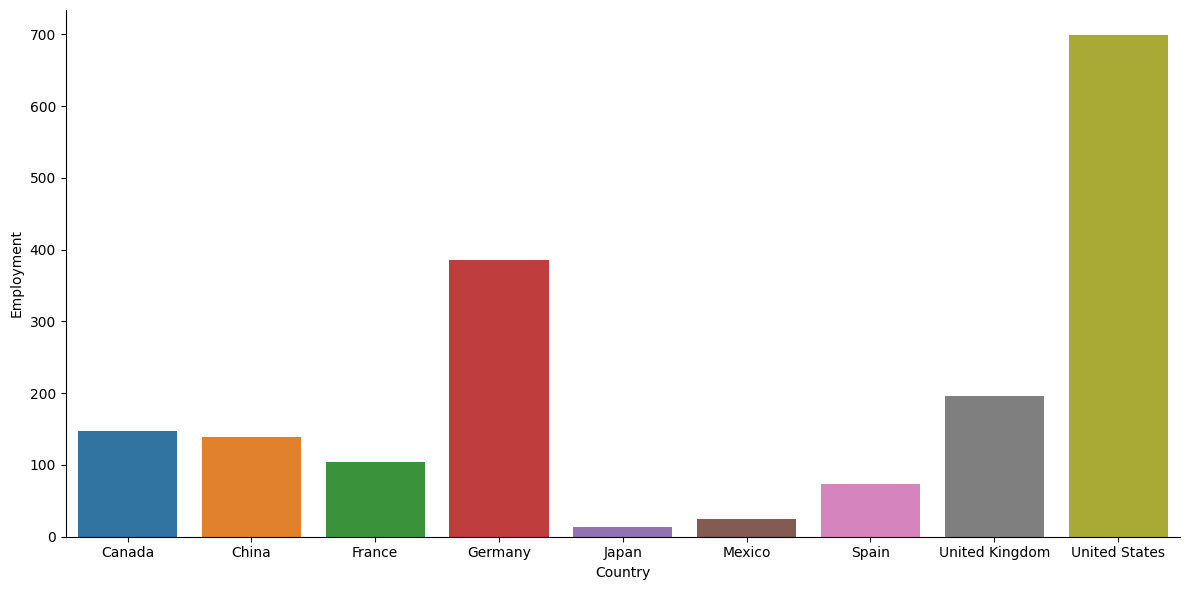

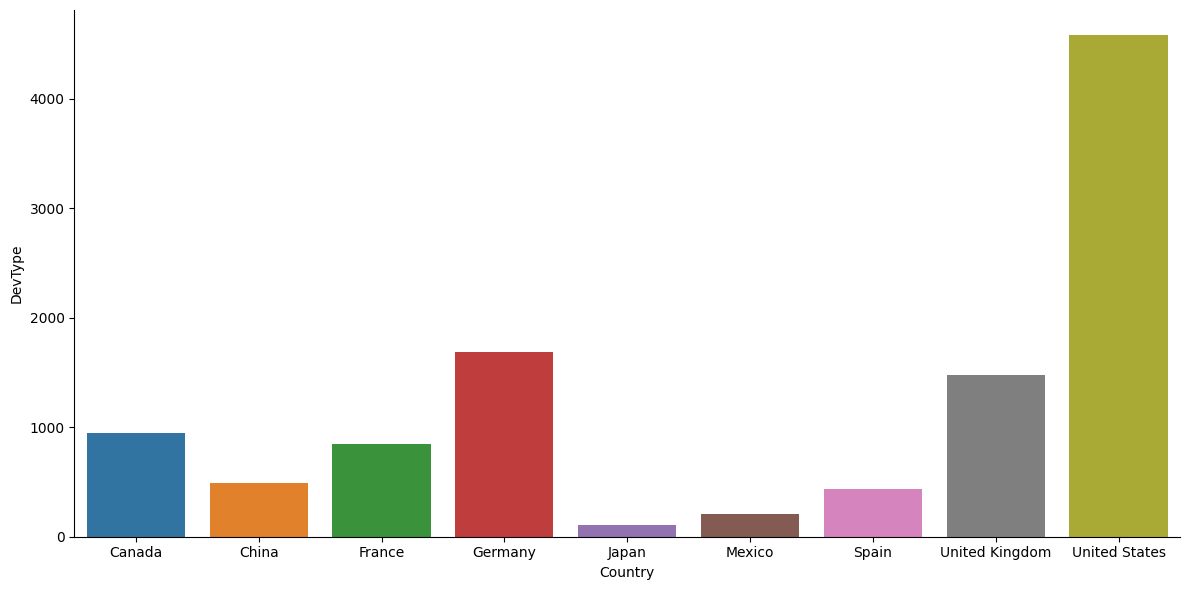

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df[['RespondentID','Country']].groupby('Country').count()

missingData = df[['Employment','DevType']].isnull().groupby(df['Country']).sum().reset_index()

A=sns.catplot(
    data=missingData, kind="bar",
    x="Country", y="Employment",
    height = 6, aspect = 2, hue='Country')
B=sns.catplot(
    data=missingData, kind="bar",
    x="Country", y="DevType",
    height = 6, aspect = 2, hue='Country')

<Figure size 640x480 with 0 Axes>

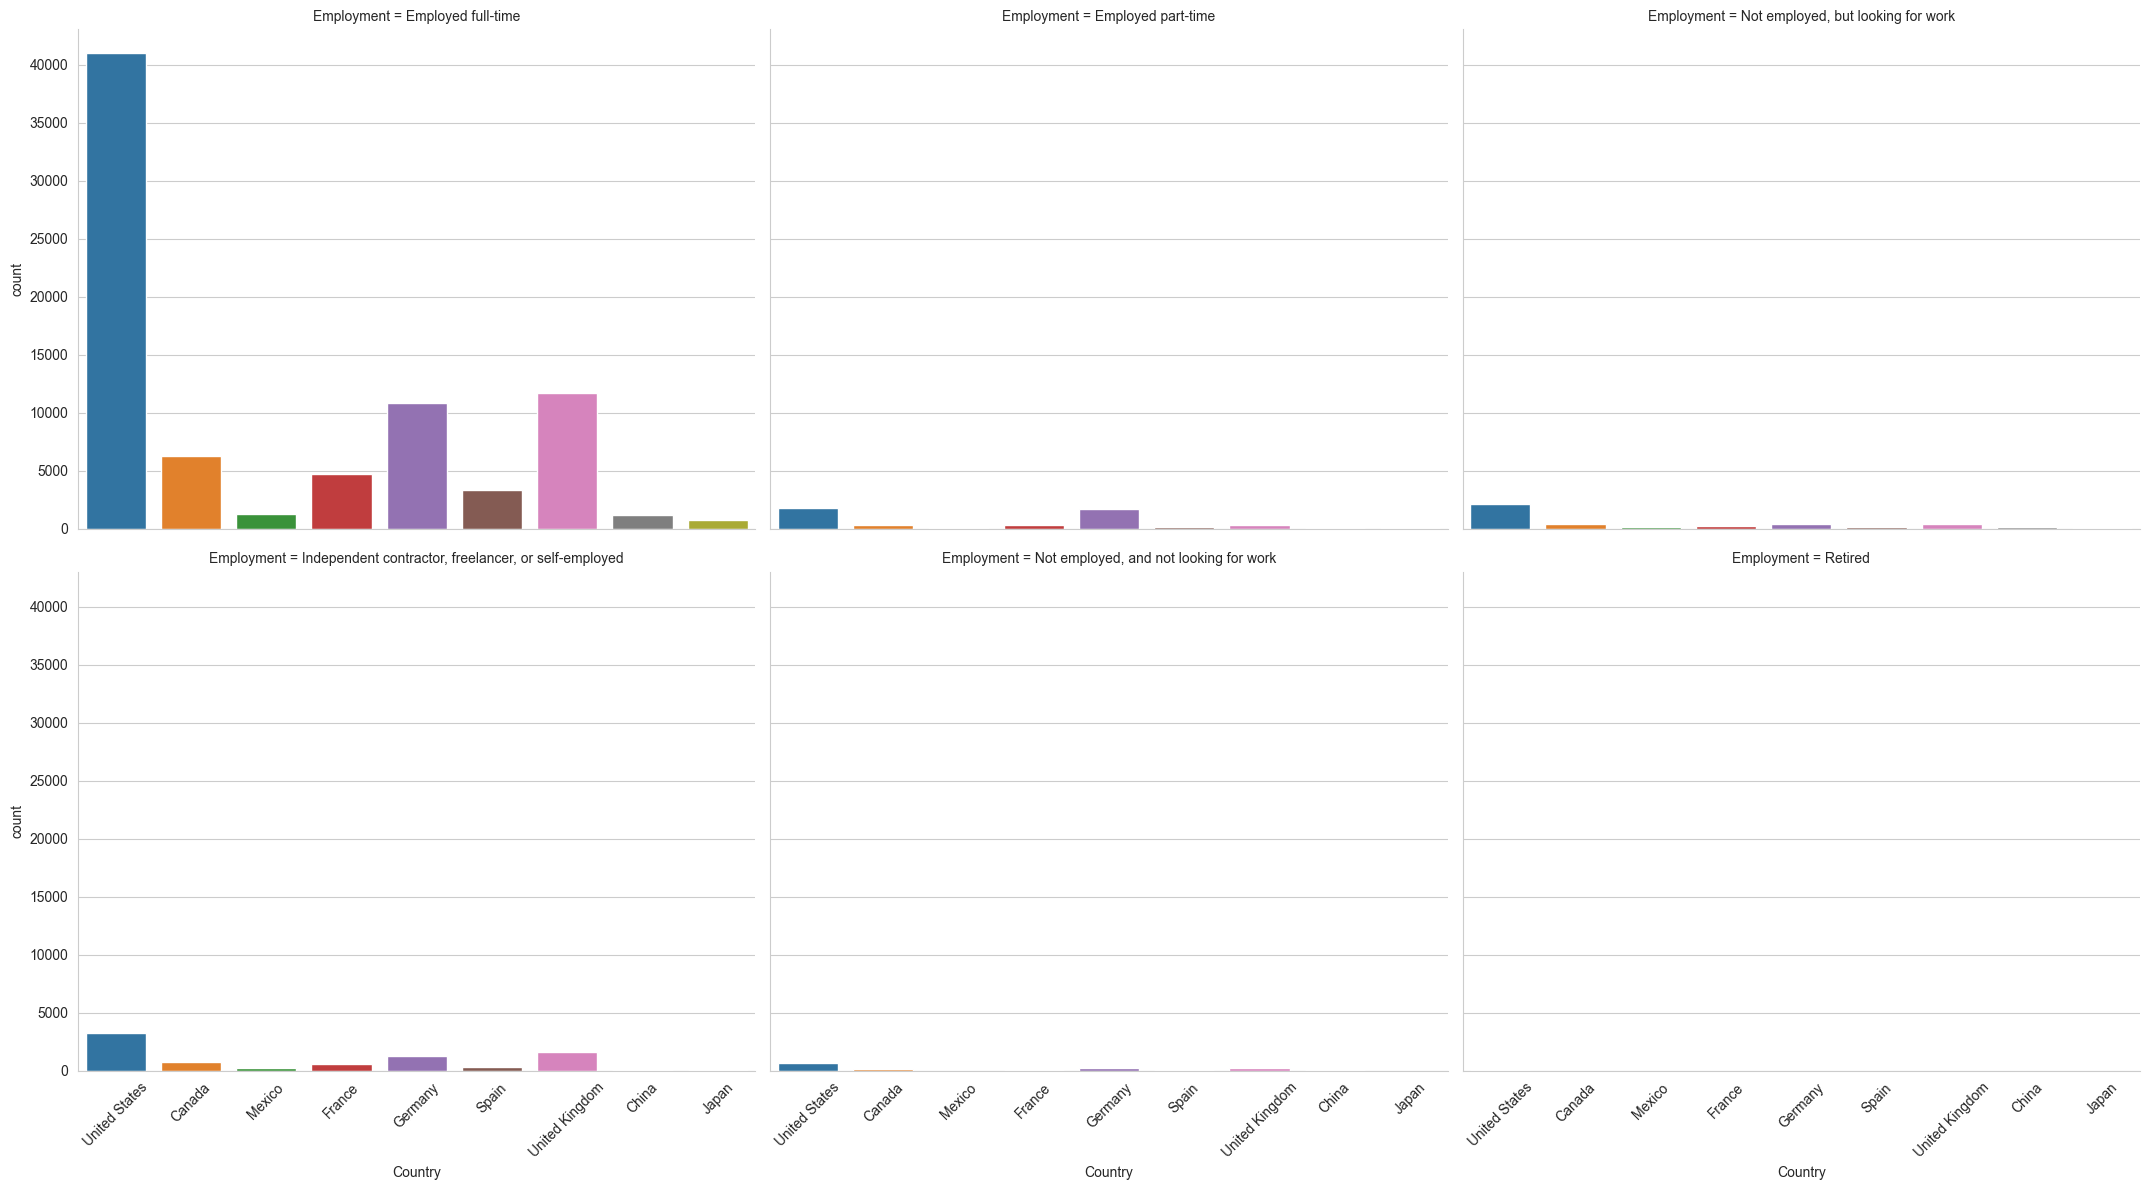

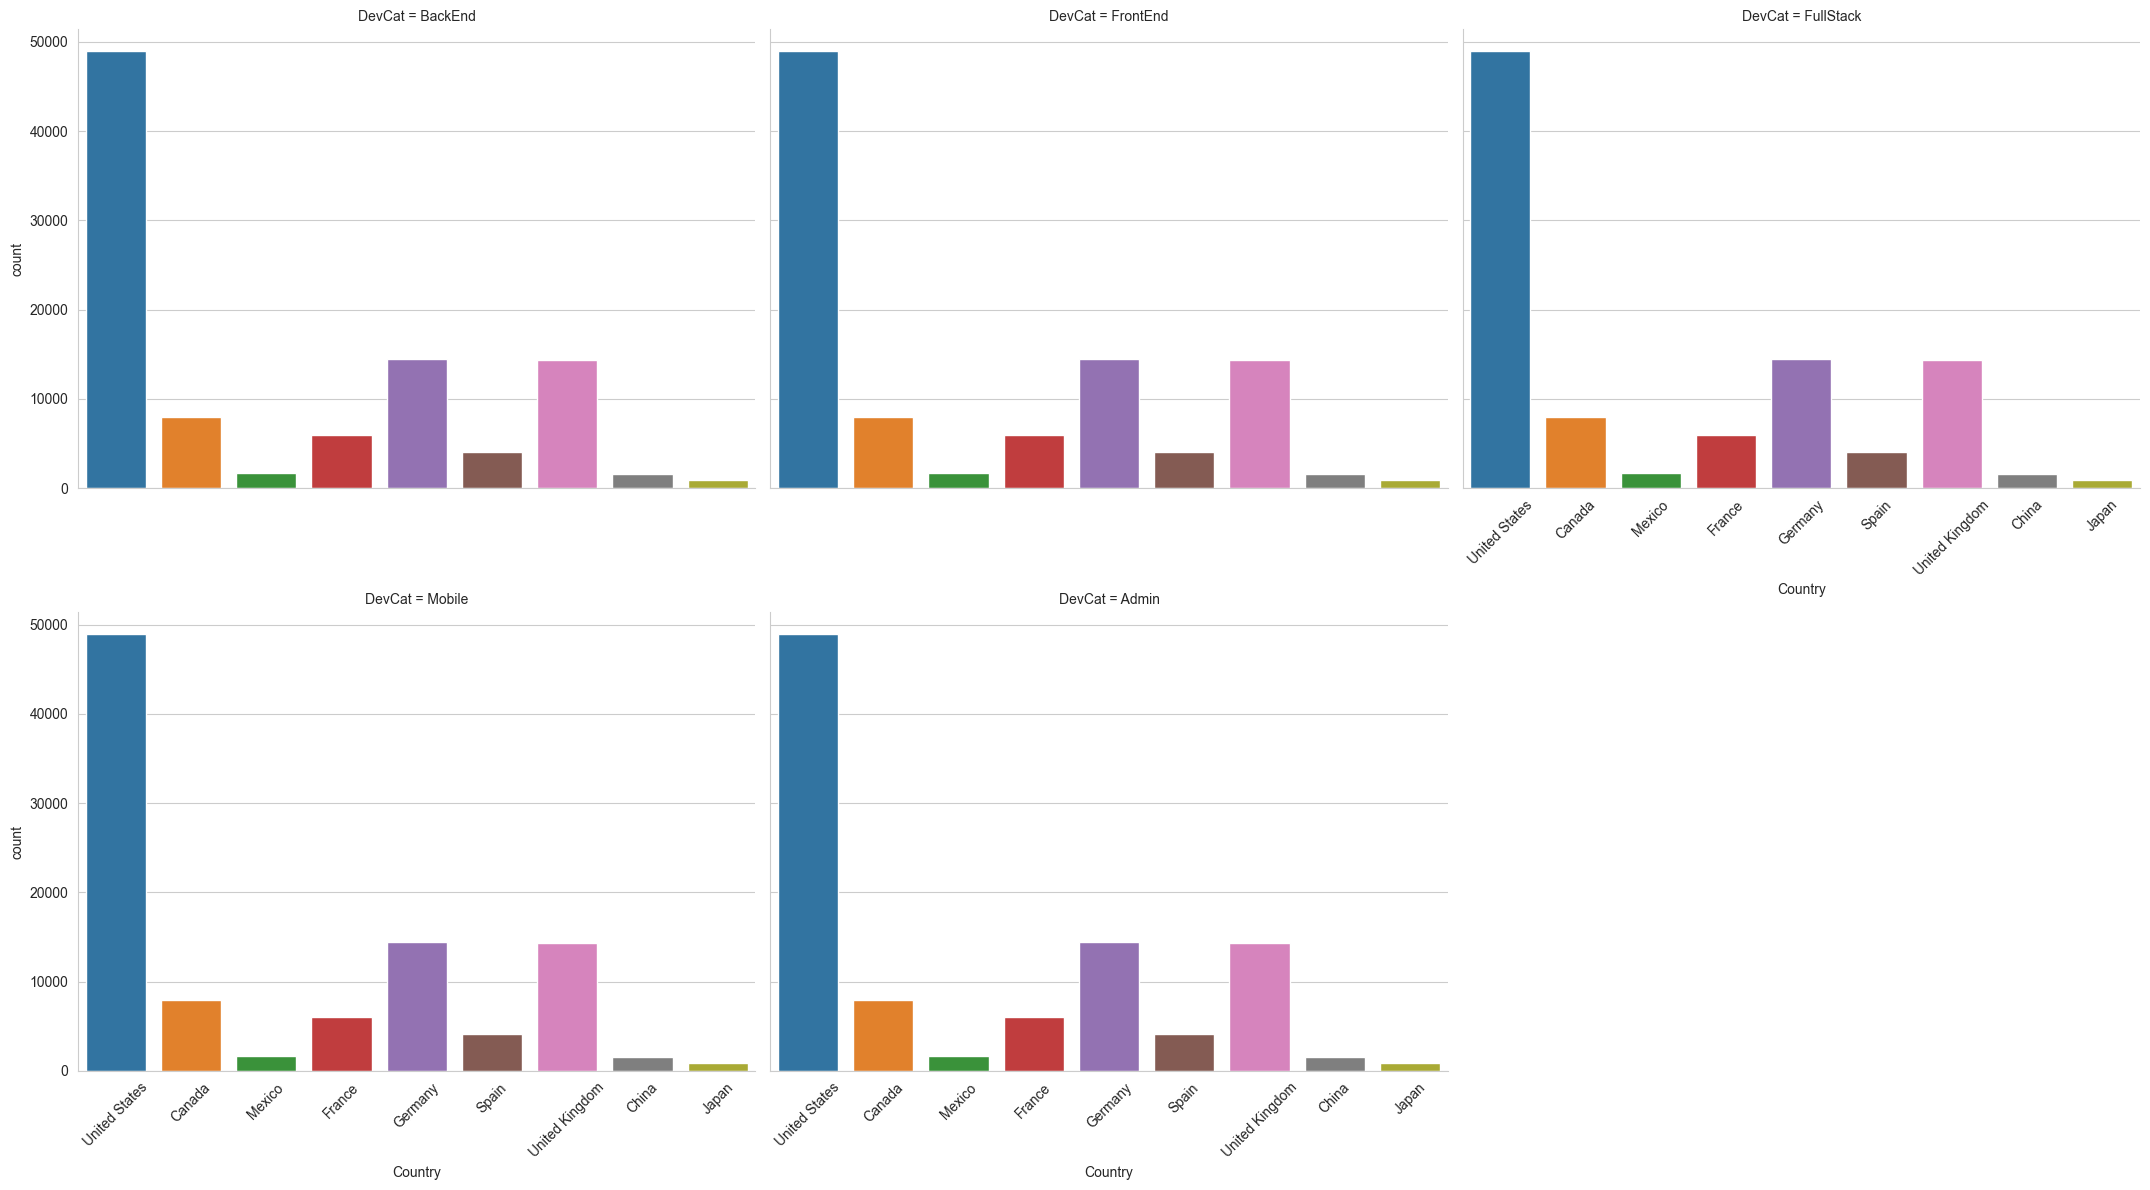

In [32]:
# Set overall visual style (clean grid background)
sns.set_style("whitegrid")

# Remove top and right borders for cleaner look
sns.despine()


# -------- EMPLOYMENT DISTRIBUTION --------
empfig = sns.catplot(
    x="Country",              # x-axis → categories to compare
    col="Employment",         # split into multiple subplots by employment type
    data=df,
    kind="count",             # count frequency of records
    height=6,                 # height of each subplot
    aspect=1.2,               # width = height * aspect
    col_wrap=3,               # wrap into multiple rows (prevents long horizontal plots)
    hue='Country',            # color by country (⚠ redundant here, same as x)
)

# Rotate x-axis labels for readability
for ax in empfig.axes.flat:
    ax.tick_params(axis='x', rotation=45)

# Adjust spacing between subplots
empfig.tight_layout()


# -------- DEV TYPE ANALYSIS --------

# Select only relevant columns (avoid unnecessary data clutter)
devdf = df.loc[:, ['Country', 'DevType']].copy()

# Create boolean flags for each developer type
# Converts messy text into structured features (VERY IMPORTANT STEP)
devdf['BackEnd']   = devdf['DevType'].str.contains('back-end', na=False)
devdf['FrontEnd']  = devdf['DevType'].str.contains('front-end', na=False)
devdf['FullStack'] = devdf['DevType'].str.contains('full-stack', na=False)
devdf['Mobile']    = devdf['DevType'].str.contains('mobile', na=False)
devdf['Admin']     = devdf['DevType'].str.contains('administrator', na=False)

# Convert from wide format → long format (required for seaborn faceting)
devdf = devdf.melt(
    id_vars=['Country'], 
    value_vars=['BackEnd','FrontEnd','FullStack','Mobile','Admin'], 
    var_name='DevCat',        # category name (type of developer)
    value_name='DevFlag'      # boolean flag
)


# Keep only the rows where DevFlag is True. Remove everything else.
# devdf = devdf[devdf['DevFlag'] == True]

# Drop any row where at least one column has a missing value (NaN).
# the missing data for these two columns can be categorized as MCAR.
devdf.dropna(how='any', inplace=True)


# -------- DEV CATEGORY PLOT --------
devFig = sns.catplot(
    x="Country",              # compare countries
    col="DevCat",             # separate plots by developer type
    data=devdf,
    kind="count",
    height=6,
    aspect=1.2,
    col_wrap=3,
    hue='Country',            # ⚠ again redundant, can remove
)

# Force same y-axis scale across plots (good for comparison, bad for detail)
# devFig.set(ylim=(0, devdf.shape[0]))

# Rotate labels for readability
for ax in devFig.axes.flat:
    ax.tick_params(axis='x', rotation=45)

# Adjust layout spacing
devFig.tight_layout()

You see that the vast majority of respondents are employed full-time. Since these developers are mainly employed, this data will be relevant for a client who wants to see what developers look for in a potential job. You also see that the majority of developers will have skill sets in front-end, back-end, or full-stack development. the market values developers who can excel in at least a major part of the development lifecycle, if not the entire stack.

#### Investigate developer undergraduate majors

overall trend of majors year over year for respondents. you are missing about 11% of the data for UndergradMajor. 

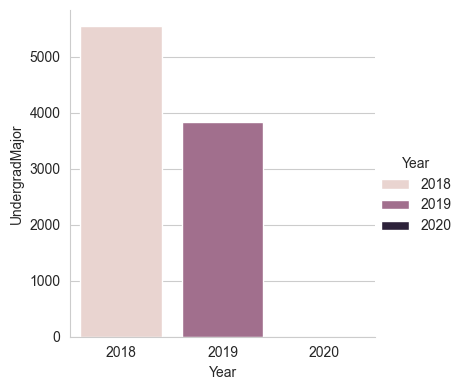

In [34]:
missingUndergrad = df['UndergradMajor'].isnull().groupby(df['Year']).sum().reset_index()

sns.catplot(x="Year", y="UndergradMajor",
                data=missingUndergrad, kind="bar",
                height=4, aspect=1, hue='Year')

all of the data for 2020 undergrad majors is filled in, indicating that each participant in these surveys had some level of decision for their undergrad major.
you are most interested in what major a person ultimately landed on, as this would be the educational background they would carry into a job search. You want to carry that value backwards for each participant to fill in any missing data.

In [37]:
# Sort by ID and Year so that each person's data is carried backwards correctly
df = df.sort_values(['RespondentID', 'Year'])

df['UndergradMajor'] = (
    df.groupby('RespondentID')['UndergradMajor']
      .bfill()
)

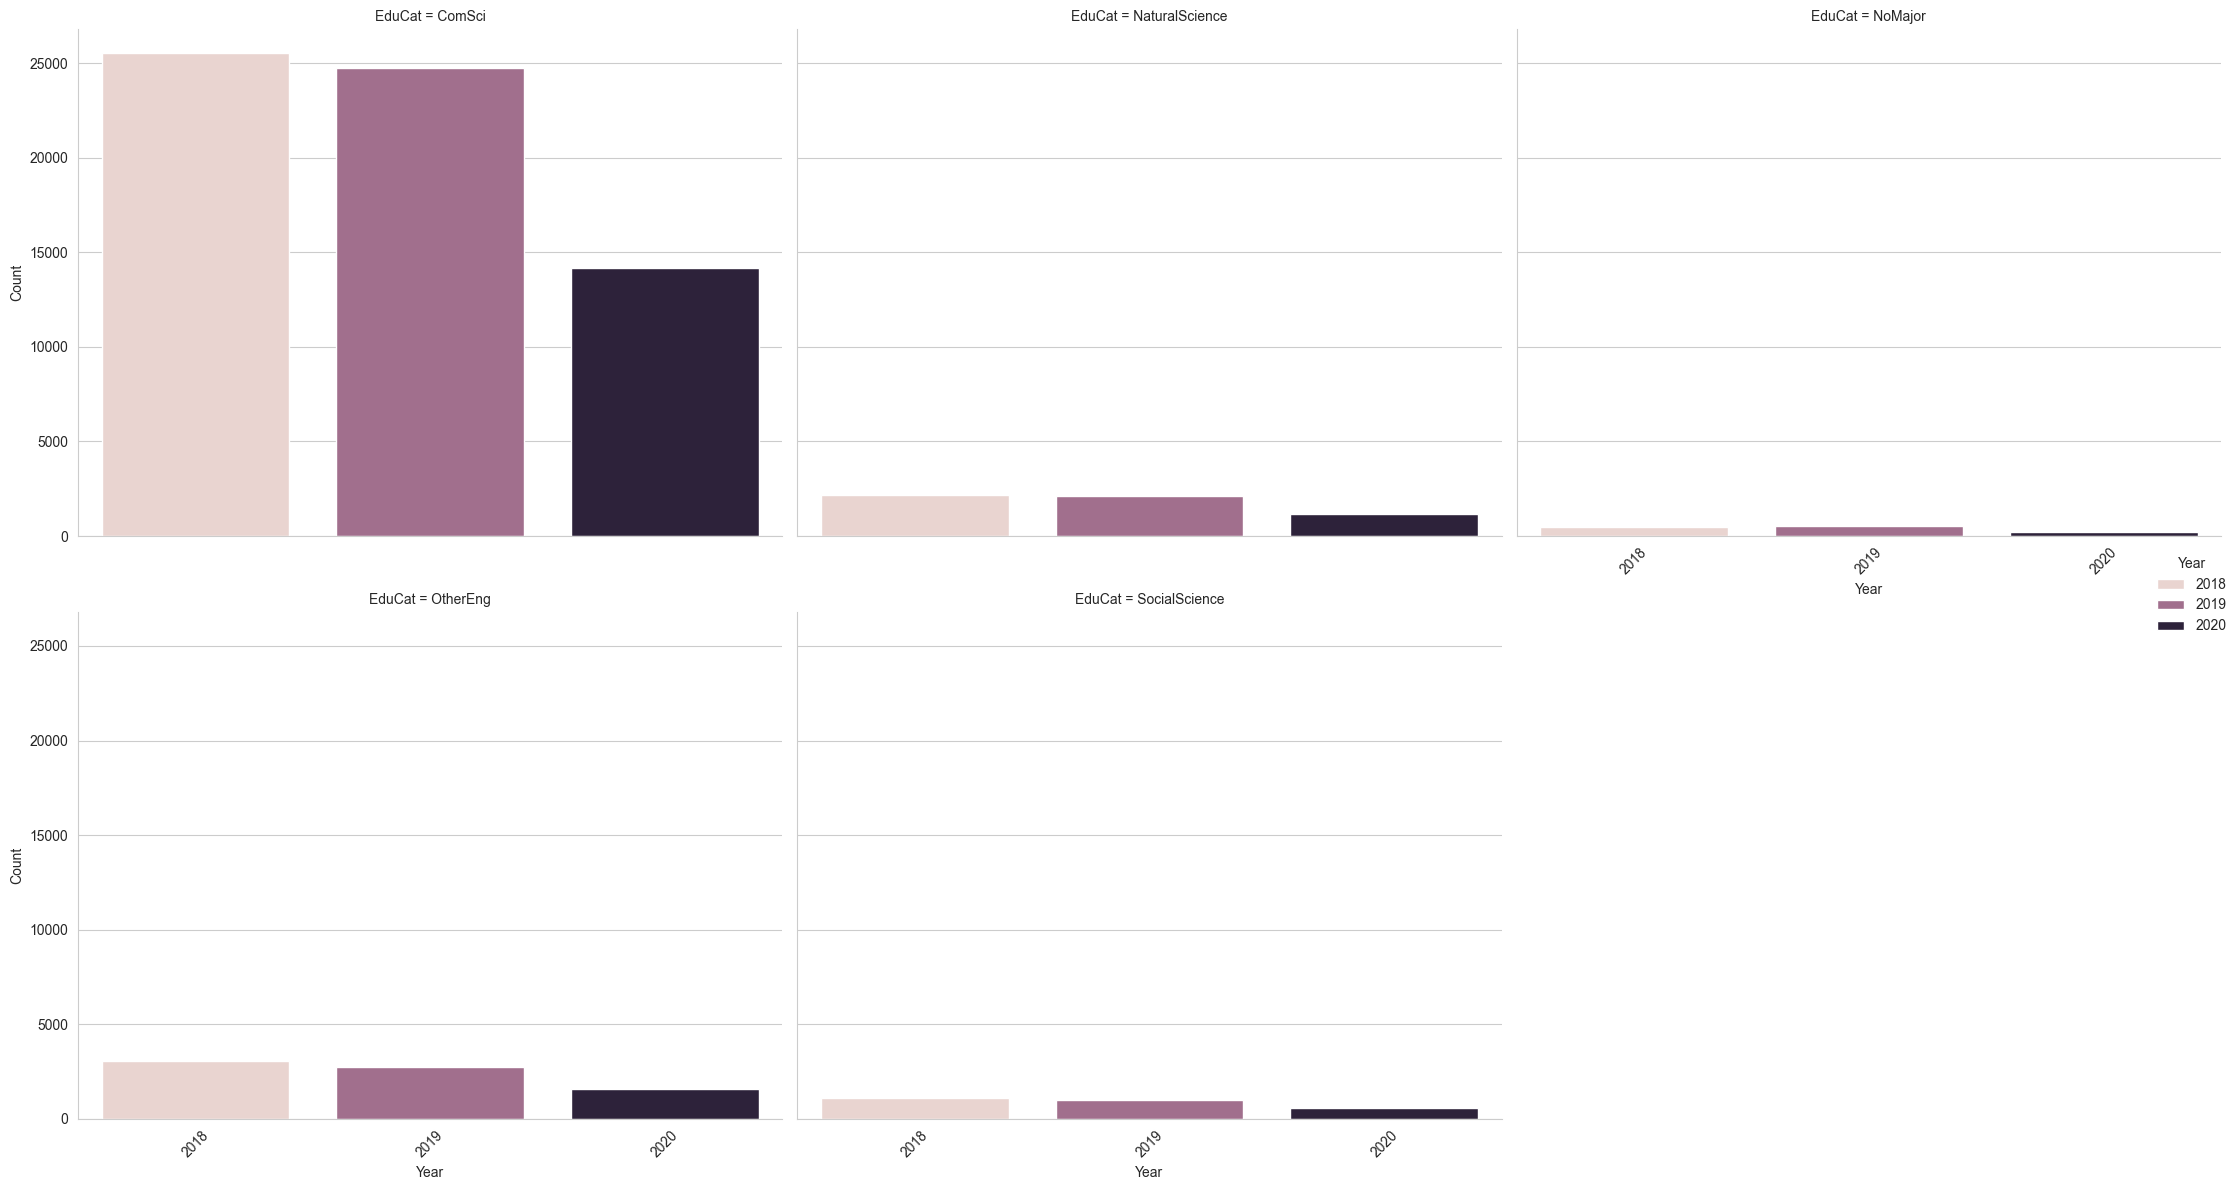

In [40]:
# -------- STEP 1: Safe copy (prevents SettingWithCopyWarning) --------
edudf = df.loc[:, ['Year', 'UndergradMajor']].copy()

# Drop missing values safely (no inplace)
edudf = edudf.dropna(subset=['UndergradMajor'])


# -------- STEP 2: Create category flags (vectorized, clean) --------
edudf['SocialScience'] = edudf['UndergradMajor'].str.contains('social science', case=False, na=False)
edudf['NaturalScience'] = edudf['UndergradMajor'].str.contains('natural science', case=False, na=False)
edudf['ComSci'] = edudf['UndergradMajor'].str.contains('computer science|development', case=False, na=False)
edudf['OtherEng'] = edudf['UndergradMajor'].str.contains('another engineering', case=False, na=False)
edudf['NoMajor'] = edudf['UndergradMajor'].str.contains('never declared', case=False, na=False)


# -------- STEP 3: Convert wide → long --------
edudf = edudf.melt(
    id_vars=['Year'],
    value_vars=['SocialScience','NaturalScience','ComSci','OtherEng','NoMajor'],
    var_name='EduCat',
    value_name='EduFlag'
)

# Keep only True rows (actual matches)
edudf = edudf[edudf['EduFlag']]


# -------- STEP 4: Aggregate counts --------
edudf = edudf.groupby(['Year','EduCat']).size().reset_index(name='Count')


# -------- STEP 5: Plot --------
eduFig = sns.catplot(
    x="Year",
    y='Count',
    col="EduCat",
    data=edudf,
    kind="bar",
    height=6,
    aspect=1.2,
    col_wrap=3,
    hue = 'Year'
)

# Rotate labels for readability
for ax in eduFig.axes.flat:
    ax.tick_params(axis='x', rotation=45)

eduFig.fig.tight_layout()

You notice that the vast majority of people who enter the workforce for development have some background in a Computer Science major. however, the number of Computer Science majors significantly declined over the years surveyed, indicating that there could be other majors that have successfully entered the workforce for their desired job.

#### Examine the relationship between years of experience and compensation

Years of experience are an important metric when looking to understand the general skill and technical capabilities of a potential candidate. Compensation is also important for our client to understand what the “going rate” for a particular developer is in today’s market.

<Axes: xlabel='Year', ylabel='ConvertedComp'>

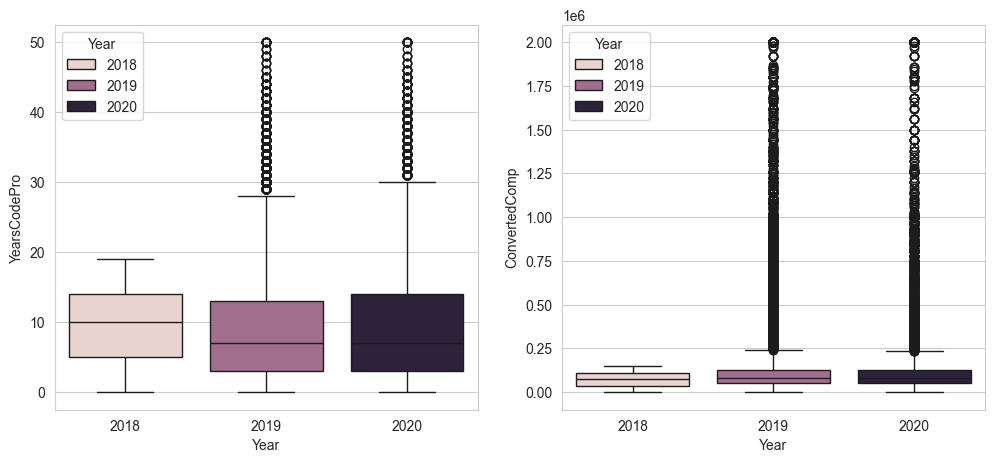

In [45]:
compFields = df[['Year','YearsCodePro','ConvertedComp']]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="Year", y="YearsCodePro", data=compFields, ax=axes[0], hue='Year')
sns.boxplot(x="Year", y="ConvertedComp", data=compFields, ax=axes[1], hue='Year')

You see that although there are some outlier data points for each column, the overall distribution is fairly consistent year-over-year. This indicates that there is a strong correlation between the data points, which should tell a good story about how experience can translate into compensation. Since there is a clear trend with the data points, you decide the best method for filling in the missing data for these two columns is through Multiple Imputation:

In [47]:
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split

imputedf = df[['YearsCodePro','ConvertedComp']]

traindf, testdf = train_test_split(imputedf, train_size=0.1)

# Create the IterativeImputer model to predict missing values
imp = IterativeImputer(max_iter=20, random_state=0)

# Fit the model to the the test dataset
imp.fit(imputedf)

# Transform the model on the entire dataset
compdf = pd.DataFrame(np.round(imp.transform(imputedf),0), columns=['YearsCodePro','ConvertedComp'])

The above code will loop through (up to 20 times), and fill in the missing data based on the context provided by the other column. This should create data points that are indicative of the overall trend of the data. Now, you can analyze the relationship between YearsCodePro and CinvertedComp through the use of a boxplot like so:

<Axes: xlabel='CodeYearBins', ylabel='ConvertedComp'>

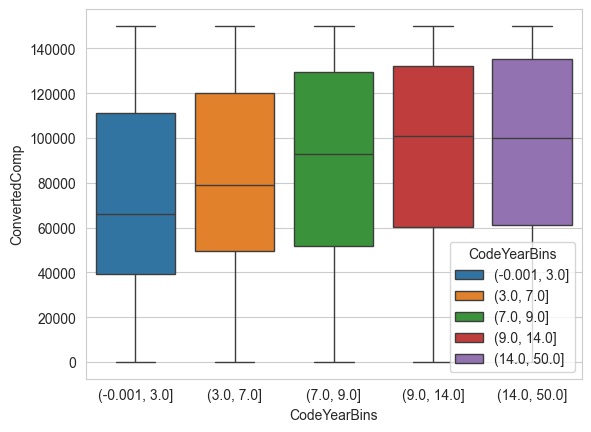

In [50]:
compPlotdf = compdf.loc[compdf['ConvertedComp'] <= 150000].copy()

compPlotdf['CodeYearBins'] = pd.qcut(
    compPlotdf['YearsCodePro'],
    q=5
)

sns.boxplot(x="CodeYearBins", y="ConvertedComp",
            data=compPlotdf, hue='CodeYearBins')

The plot above validates your hypothesis from before. While there are high (and low) earning developers at every experience level, experience appears to correlate with compensation. The more experienced a developer was, the more (on average) they were compensated.

### Summary and Results

We have analyzed information about the developer community from a variety of points of view. Our client understands the global presence of the developer community, their varied backgrounds, and how their experience translates into compensation. Overall, these statistical analyses can guide actions in moving forward with a staffing plan that aligns with your client’s growth plan and technical requirements.